# Regression

## Imports

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from dataset import CaliforniaHousingDataset as Dataset
from pipeline import get_pipeline
from eda.eda import EDA
plt.rcParams['figure.figsize'] = (12, 8)

# Linear regression
from linear_regression.diagnostics import GaussMarkovDiagnostics
from linear_regression.ols import OLS
from linear_regression.wls import WLS

# Advanced
from advanced.gpr import GPR
from advanced.irls import IRLS

# Evaluation
from evaluation.visualizer import Visualizer
from evaluation.evaluator import Evaluator

## Dataset

### Missing values

In [2]:
    d = Dataset()
    eda = EDA(d)

    print(eda.missing_values())


    # eda.plot_target_distribution()
    # eda.plot_scatter_features_target()
    # eda.plot_corrrelation_matrix()
    # eda.plot_outliers()
    # plt.show()

                 feature  missing_count  missing_percent
MedInc            MedInc              0              0.0
HouseAge        HouseAge              0              0.0
AveRooms        AveRooms              0              0.0
AveBedrms      AveBedrms              0              0.0
Population    Population              0              0.0
AveOccup        AveOccup              0              0.0
Latitude        Latitude              0              0.0
Longitude      Longitude              0              0.0
MedHouseVal  MedHouseVal              0              0.0


### Descriptive statistics

In [3]:
print(eda.descriptive_stats())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

### Target distribution

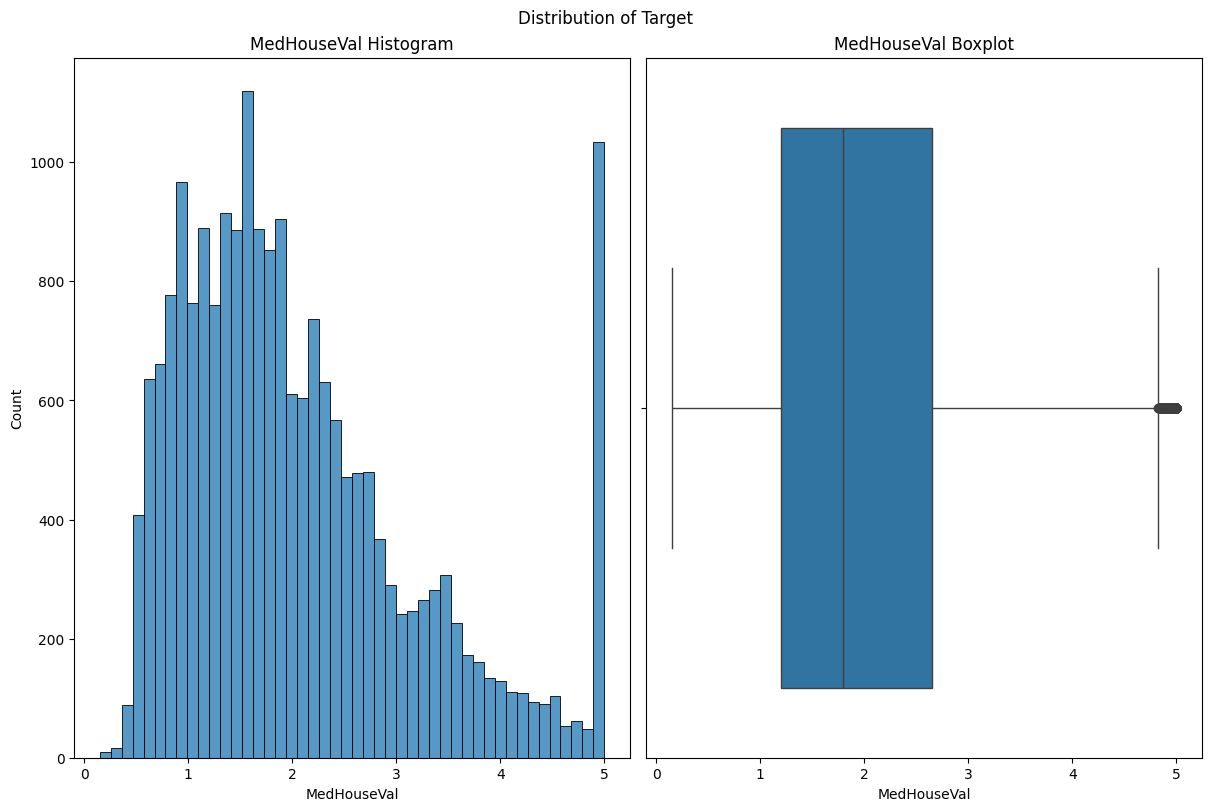

In [4]:
eda.plot_target_distribution()
plt.show()

### Scatter

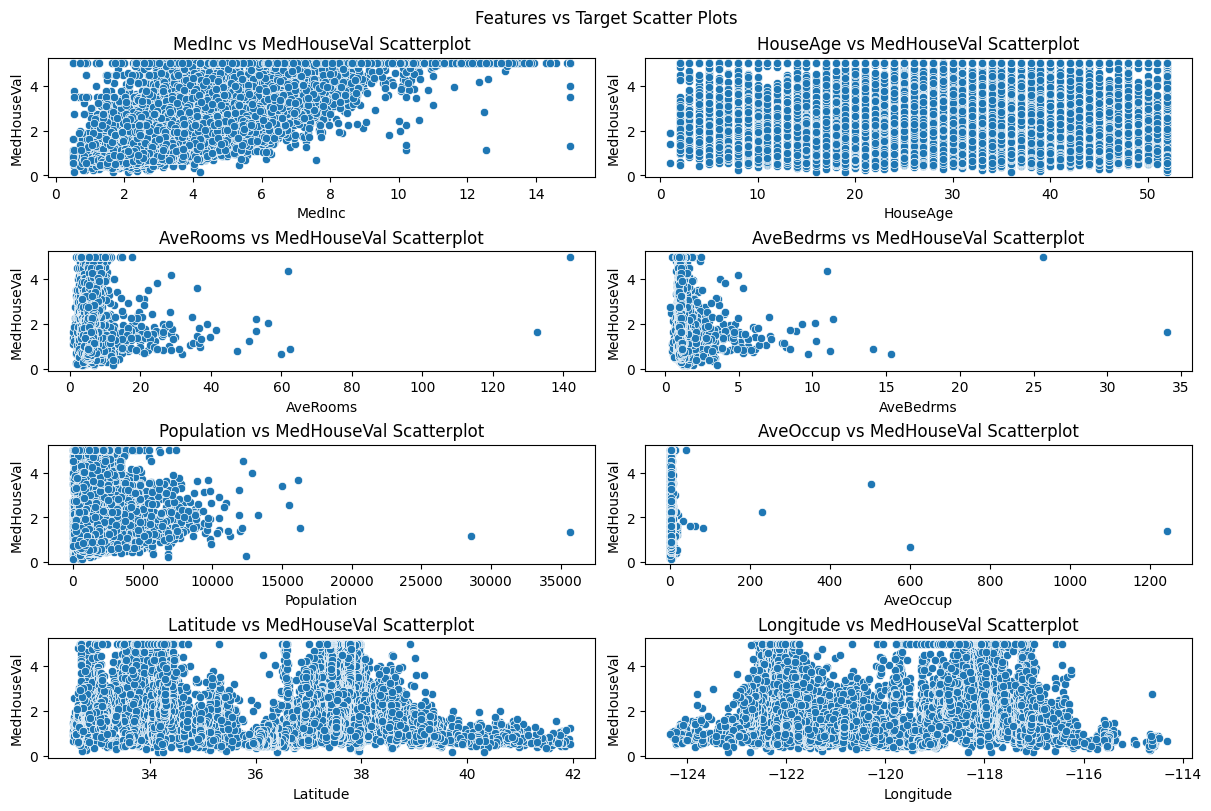

In [5]:
eda.plot_scatter_features_target()
plt.show()

### Correlation matrix

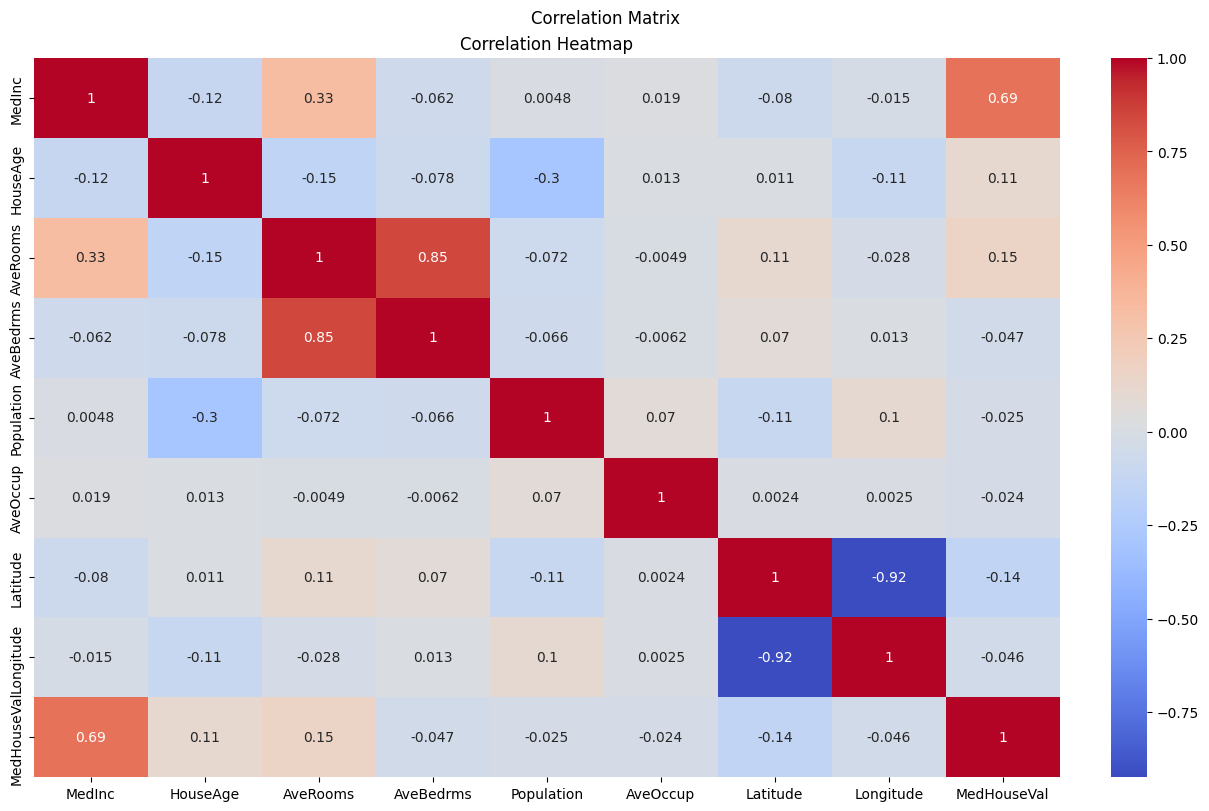

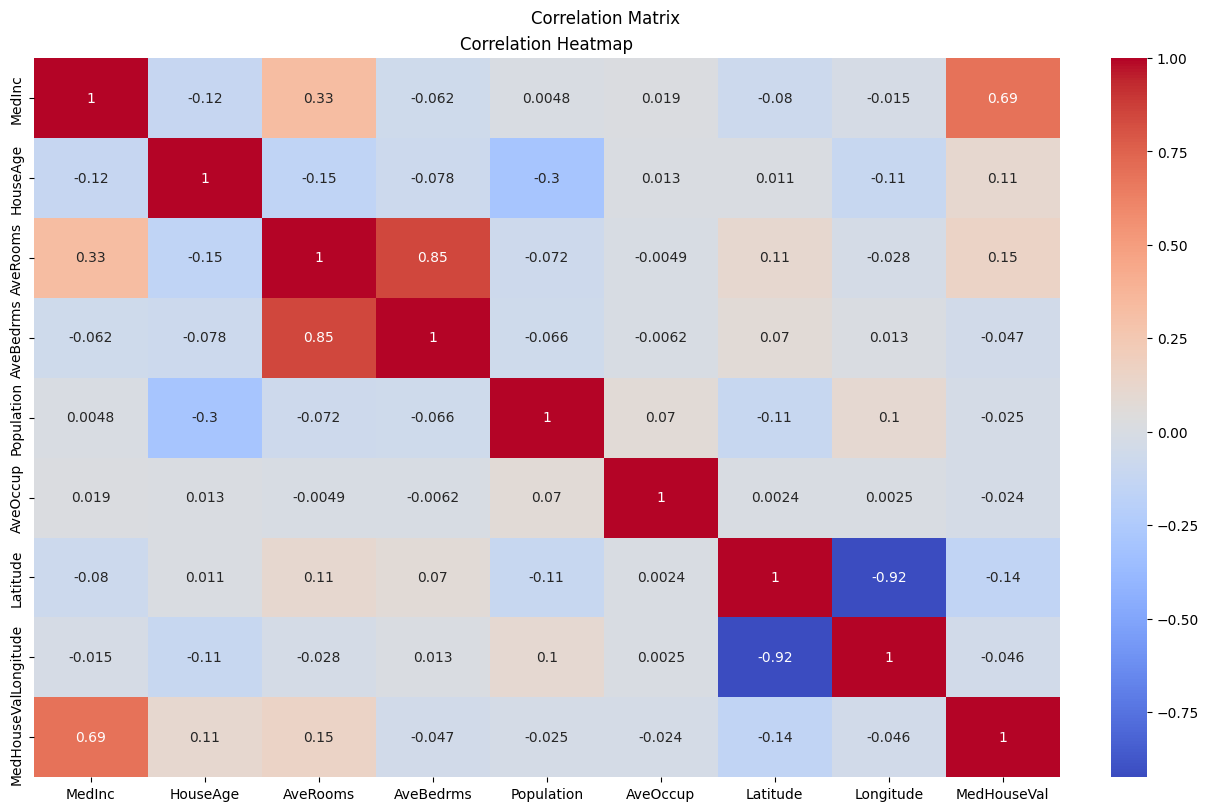

In [6]:
eda.plot_corrrelation_matrix()

### Outliers

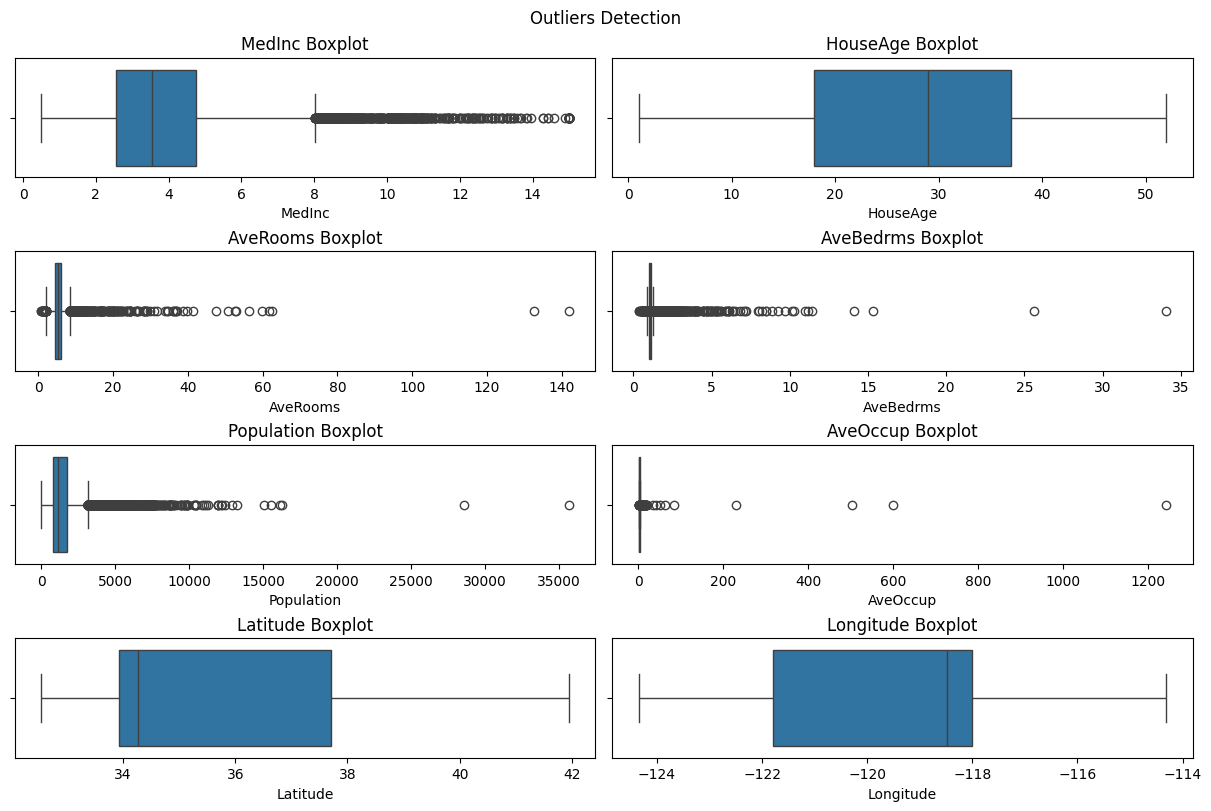

In [7]:
eda.plot_outliers()
plt.show()

### Preprocessing

In [8]:
d.split()

## Models

### Linear regression

#### Gauss-Markov hypothesis

In [9]:
model = get_pipeline(OLS())
model.fit(d.X_train, d.y_train)
y_pred_train = model.predict(d.X_train)
diag = GaussMarkovDiagnostics()

##### Residuals plot

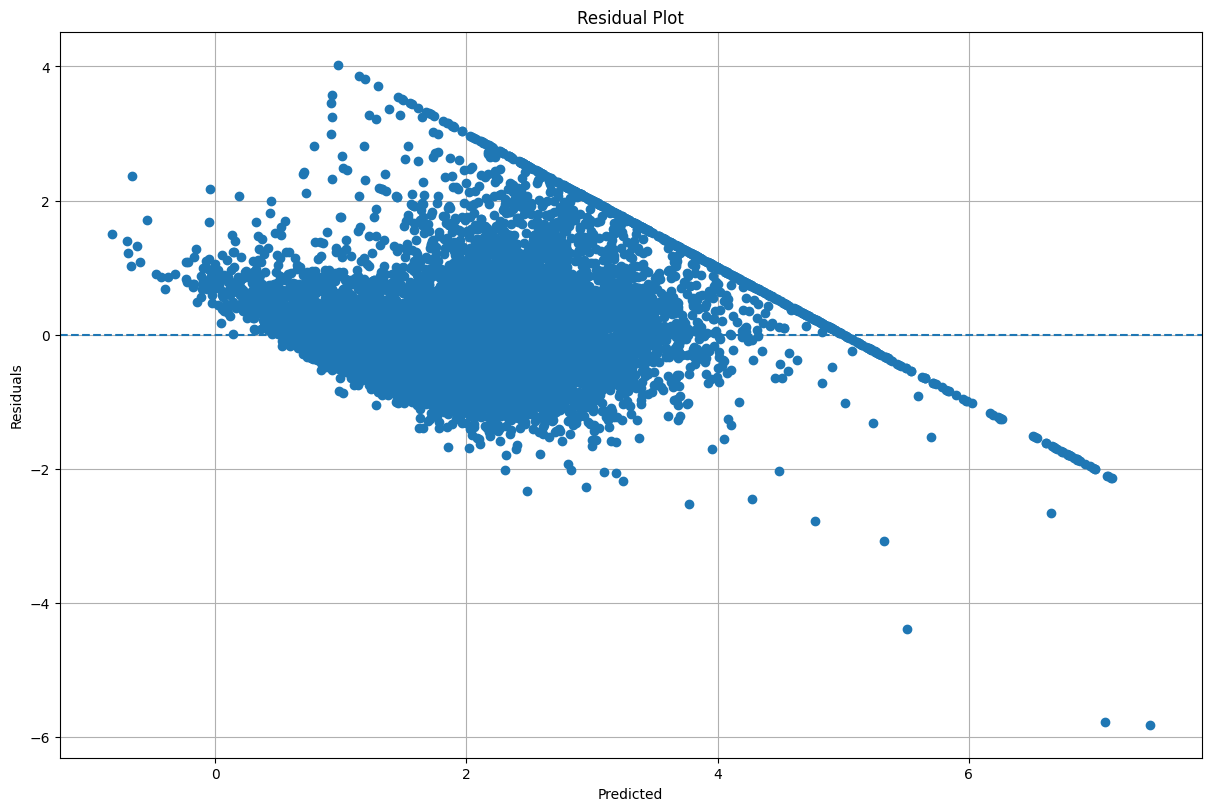

In [10]:
residuals_train = d.y_train - y_pred_train
diag.plot_residuals(d.y_train, y_pred_train)

plt.show()

##### QQ-plot

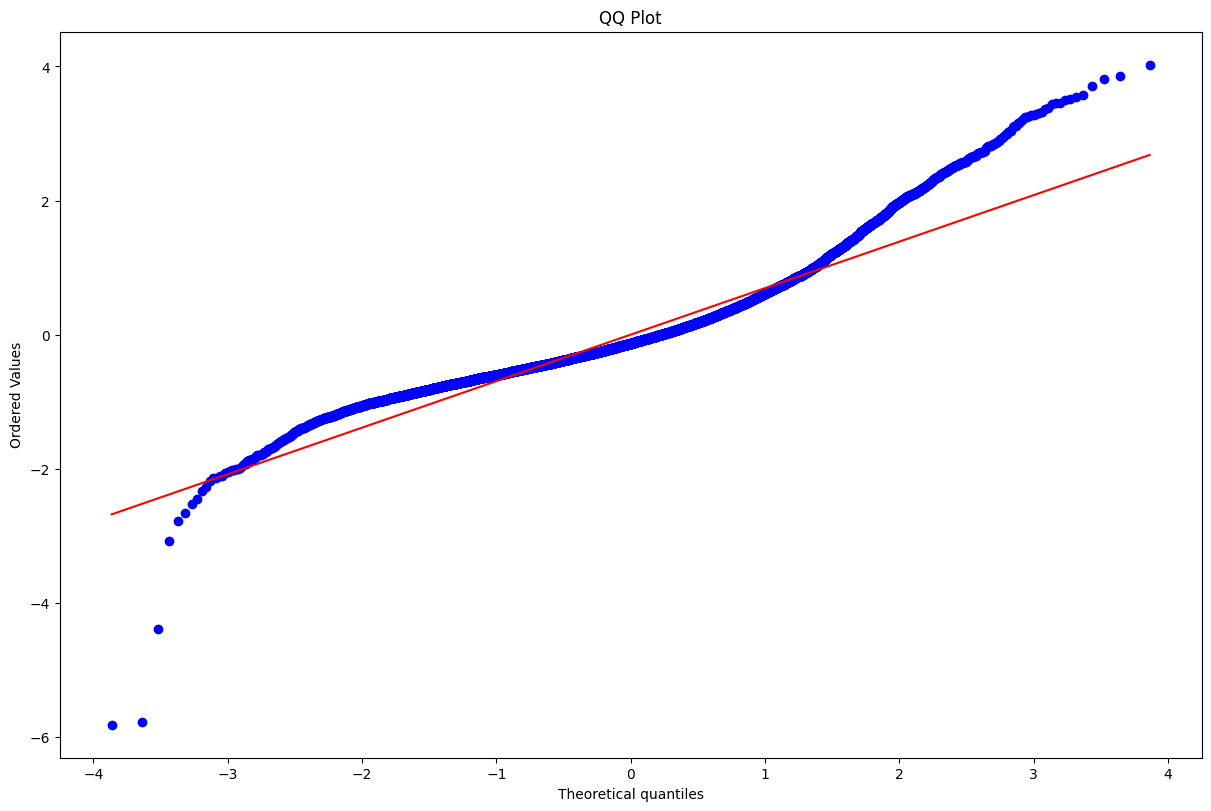

In [11]:
diag.plot_qq(residuals_train)
plt.show()

##### Breusch–Pagan test

{'LM Stat': np.float64(1248.6155930277985), 'LM p-value': np.float64(2.997109297657453e-264), 'F Stat': np.float64(173.45177991839563), 'F p-value': np.float64(1.049113595267111e-278)}


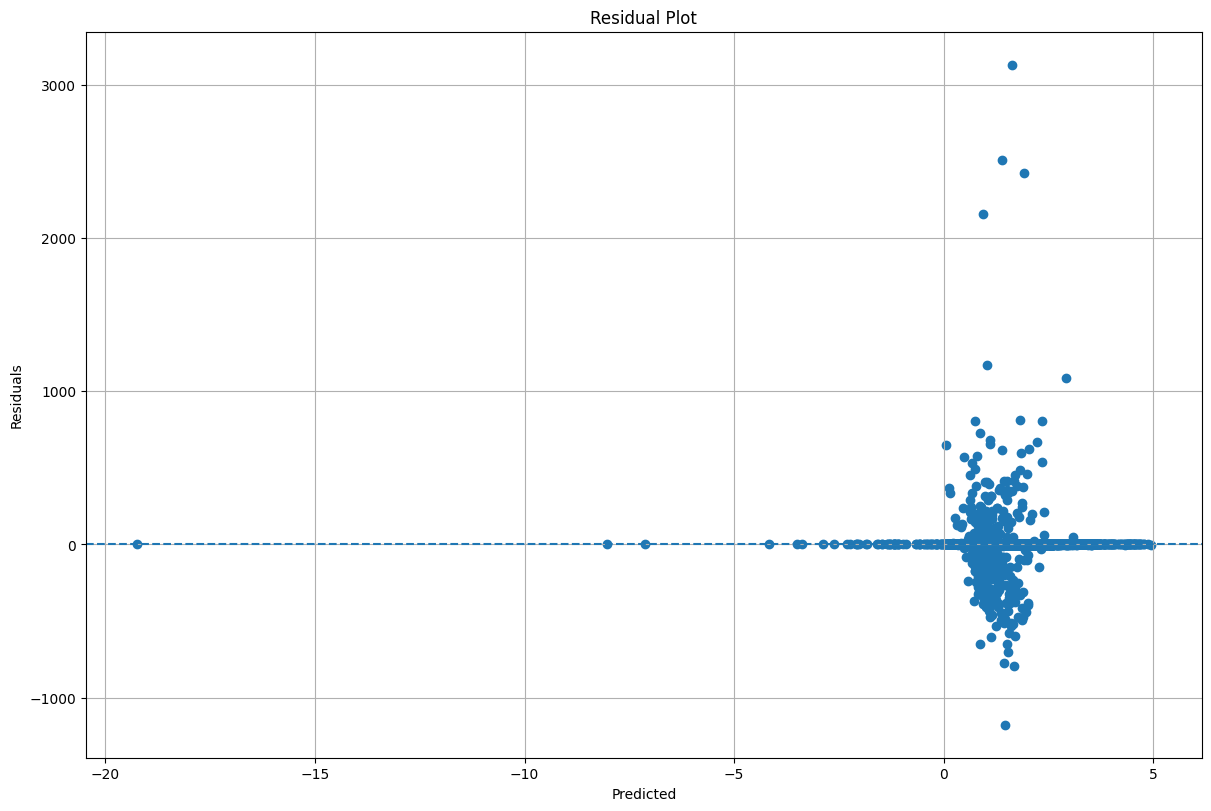

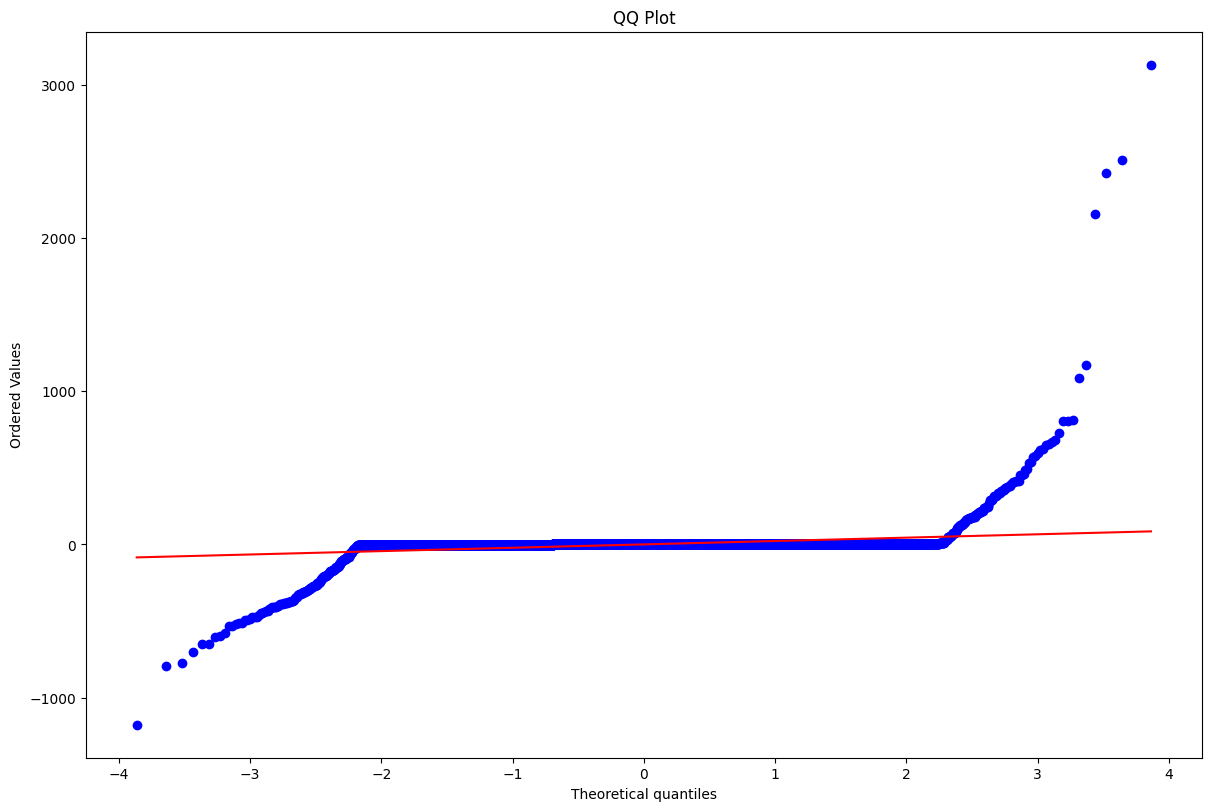

In [12]:
result = diag.breusch_pagan_test(d.X_train, residuals_train)
print(result)

if result["LM p-value"] < 0.05:
    aux = get_pipeline(OLS())
    aux.fit(d.X_train, np.square(residuals_train))

    sigma2_hat = aux.predict(d.X_train)
    sigma2_hat = np.clip(sigma2_hat, 1e-6, None)

    weights = 1.0 / sigma2_hat

    wls = get_pipeline(WLS(weights=weights))
    wls.fit(d.X_train, d.y_train)

    y_pred_train = wls.predict(d.X_train)
    residuals_train = d.y_train - y_pred_train
    weighted_residuals = np.sqrt(weights) * residuals_train

    diag.plot_residuals_direct(y_pred_train, weighted_residuals)
    plt.show()
    diag.plot_qq(weighted_residuals)
    plt.show()

#### Regularization and features selectin

#### Non-linear basis and Ablation study

### Advanced

#### Gaussian Process Regression

In [13]:
rng = np.random.default_rng(42)
idx = rng.choice(len(d.X_train), 2000, replace=False)
X_sub = d.X_train[idx]
y_sub = d.y_train[idx]

model = get_pipeline(GPR())
model.fit(X_sub, y_sub)

y_pred, y_std = model.predict(d.X_test)
y_true = d.y_test
print("min std:", y_std.min())
print("max std:", y_std.max())

X_test = d.X_test

/home/PhuHoang/Projects/course-ml/supervised-learning-project/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


min std: 0.002857790467257898
max std: 0.04427455951736431


In [14]:
mean_squared_error(y_true, y_pred)

0.5427983783466228

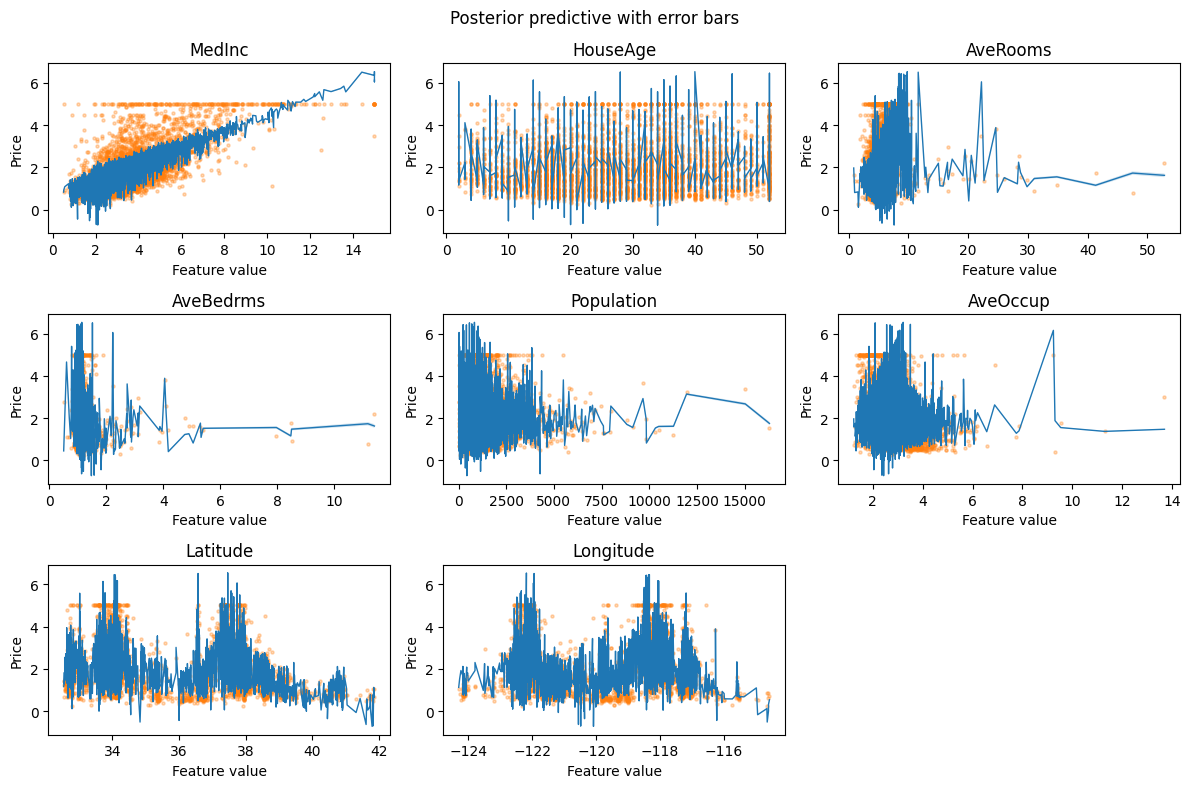

In [17]:
feature_names = getattr(d, "feature_names", [f"Feature {i}" for i in range(X_test.shape[1])])

n_features = X_test.shape[1]

for i in range(n_features):
    x_plot = X_test[:, i]
    idx = np.argsort(x_plot)

    plt.subplot(3, 3, i+1)

    # Prediction mean
    plt.plot(x_plot[idx], y_pred[idx], label="Pred", linewidth=1)

    # Uncertainty band
    plt.fill_between(
        x_plot[idx],
        y_pred[idx] - 1.96*y_std[idx],
        y_pred[idx] + 1.96*y_std[idx],
        # color="red",
        alpha=0.2
    )

    # True points
    plt.scatter(x_plot, y_true, s=5, alpha=0.3)

    plt.title(feature_names[i])
    plt.xlabel("Feature value")
    plt.ylabel("Price")
plt.gcf().suptitle("Posterior predictive with error bars")
plt.tight_layout()
plt.show()

#### Robust Regression

In [29]:
huber = get_pipeline(IRLS(loss="huber"))
huber.fit(d.X_train, d.y_train)
y_pred_huber = huber.predict(d.X_test)

student = get_pipeline(IRLS(loss="student-t"))
student.fit(d.X_train, d.y_train)
y_pred_student = student.predict(d.X_test)

model_ols = get_pipeline(OLS())
model_ols.fit(d.X_train, d.y_train)
y_pred_ols = model_ols.predict(d.X_test)

y_true = d.y_test

print("=== Overall MSE ===")
print(f"OLS: {mean_squared_error(y_true, y_pred_ols):.4f}")
print(f"Huber IRLS: {mean_squared_error(y_true, y_pred_huber):.4f}")
print(f"Student-t IRLS: {mean_squared_error(y_true, y_pred_student):.4f}")

=== Overall MSE ===
OLS: 0.5253
Huber IRLS: 0.5180
Student-t IRLS: 0.5237


In [31]:
# ===== TRAIN CLEAN =====
model_ols.fit(d.X_train, d.y_train)
huber.fit(d.X_train, d.y_train)
student.fit(d.X_train, d.y_train)

y_ols_clean = model_ols.predict(d.X_test)
y_huber_clean = huber.predict(d.X_test)
y_student_clean = student.predict(d.X_test)

# ===== ADD OUTLIER =====
y_train_noisy = d.y_train.copy()

idx = np.random.choice(len(d.y_train), int(0.1 * len(d.y_train)), replace=False)
y_train_noisy[idx] += 5 * np.std(d.y_train)

# ===== TRAIN NOISY =====
model_ols.fit(d.X_train, y_train_noisy)
huber.fit(d.X_train, y_train_noisy)
student.fit(d.X_train, y_train_noisy)

y_ols_noisy = model_ols.predict(d.X_test)
y_huber_noisy = huber.predict(d.X_test)
y_student_noisy = student.predict(d.X_test)

# ===== SENSITIVITY =====
print("\n=== Sensitivity ===")
print("OLS:", np.mean(np.abs(y_ols_clean - y_ols_noisy)))
print("Huber:", np.mean(np.abs(y_huber_clean - y_huber_noisy)))
print("Student:", np.mean(np.abs(y_student_clean - y_student_noisy)))


=== Sensitivity ===
OLS: 0.5748764684936356
Huber: 0.12788816088282218
Student: 0.17157908608444508


### Models evaluation

In [23]:
models = {
    "OLS": get_pipeline(OLS()),
    "IRLS (Huber)": get_pipeline(IRLS(loss="huber")),
    "IRLS (Student-t)": get_pipeline(IRLS(loss="student-t"))
}

evaluator = Evaluator()

result = evaluator.compare_models_cv(models, d.X_train, d.y_train)

print(result)

result = evaluator.compare_models_test(models, d.X_train, d.y_train,
                                       d.X_test, d.y_test)
print(result)

stat_result = evaluator.compare_models_statistical(
    models,
    d.X_train,
    d.y_train
)

print(stat_result)

              Model              MSE             RMSE              MAE  \
0               OLS  0.5345 ± 0.0384  0.7306 ± 0.0256  0.5315 ± 0.0068   
1      IRLS (Huber)  1.0015 ± 0.9877  0.9212 ± 0.3911  0.5233 ± 0.0158   
2  IRLS (Student-t)  3.8615 ± 6.2392  1.4698 ± 1.3043  0.5234 ± 0.0486   

                 R2  
0   0.5961 ± 0.0237  
1   0.2227 ± 0.8028  
2  -2.0495 ± 5.0043  
              Model       MSE      RMSE       MAE        R2
0               OLS  0.525331  0.724797  0.529916  0.609737
1      IRLS (Huber)  0.518014  0.719732  0.512925  0.615173
2  IRLS (Student-t)  0.472567  0.687435  0.490149  0.648935
        Model A           Model B  p-value (t-test)  p-value (Wilcoxon)
0           OLS      IRLS (Huber)          0.190144            0.695312
1           OLS  IRLS (Student-t)          0.144227            0.769531
2  IRLS (Huber)  IRLS (Student-t)          0.138202            0.695312
